In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F
from torch.distributions import MultivariateNormal, Categorical
from torch.distributions.mixture_same_family import MixtureSameFamily


import numpy as np
import matplotlib.pyplot as plt
from module import FlowMatchingModel

from scipy.stats import multivariate_normal, gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse

In [8]:
class BottleneckExtractor:
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
        self.model.to(self.device)
        self.model.eval()
        
        self.bottleneck_features = []
        self.model.scalar_field.bottleneck.register_forward_hook(self._hook_fn)
        
    def _hook_fn(self, module, input, output):
        pooled = torch.mean(output, dim=[2, 3])  # Global average pooling
        self.bottleneck_features.append(pooled.detach().cpu())
    
    def extract_features(self, total_mass_maps, star_maps, gas_maps, T_maps, astro_params, noise_std, batch_size=25):
        """Extract features in small batches to avoid memory issues"""
        all_batch_features = []
        n_samples = len(total_mass_maps)
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            # Clear previous features
            self.bottleneck_features = []
            
            # Get batch slices
            batch_total = total_mass_maps[i:end_idx]
            batch_star = star_maps[i:end_idx] 
            batch_gas = gas_maps[i:end_idx]
            batch_T = T_maps[i:end_idx]
            
            # Handle astro_params indexing
            astro_start = i // 15
            astro_end = min((end_idx + 14) // 15, len(astro_params))
            batch_astro = astro_params[astro_start:astro_end]
            
            # Convert to tensors
            total_mass = torch.FloatTensor(batch_total).unsqueeze(1).to(self.device)
            target_maps = torch.stack([
                torch.FloatTensor(batch_star),
                torch.FloatTensor(batch_gas),
                torch.FloatTensor(batch_T)
            ], dim=1).to(self.device)
            astro_params_tensor = torch.FloatTensor(batch_astro).to(self.device)
            
            # Create forward pass
            current_batch_size = total_mass.size(0)
            t = torch.rand(current_batch_size, device=self.device)
            
            x0 = total_mass.expand(-1, 3, -1, -1)
            noise = torch.randn_like(x0)*noise_std
            x0 = x0 + noise
            
            x1 = target_maps
            t_expanded = t.view(-1, 1, 1, 1)
            x_t = (1 - t_expanded) * x0 + t_expanded * x1
            
            # Handle astro_params batch size matching
            if astro_params_tensor.size(0) != current_batch_size:
                repeat_factor = (current_batch_size + astro_params_tensor.size(0) - 1) // astro_params_tensor.size(0)
                astro_params_tensor = astro_params_tensor.repeat(repeat_factor, 1)[:current_batch_size]
            
            condition_param = torch.cat([t.unsqueeze(1), astro_params_tensor], dim=1)
            
            with torch.no_grad():
                _ = self.model.scalar_field(x_t, condition_param, total_mass, target_maps)
            
            # Collect batch features
            if self.bottleneck_features:
                batch_features = torch.cat(self.bottleneck_features, dim=0).cpu().numpy()
                all_batch_features.append(batch_features)
            
            # Clear GPU memory immediately
            del total_mass, target_maps, astro_params_tensor, x_t, condition_param
            torch.cuda.empty_cache()
        
        # Combine all batches
        if all_batch_features:
            return np.vstack(all_batch_features)
        return np.array([])

def load_model_data(model_name, n_samples=500, data_dir="/n/netscratch/iaifi_lab/Lab/msliu/CMD/data"):
    """Load and normalize data following training pattern exactly"""
    
    # Load full datasets
    # total_mass = np.load(f'{data_dir}/{model_name}/Maps_Mtot_{model_name}_LH_z=0.00.npy')
    total_mass = np.load(f'{data_dir}/{model_name}/Maps_Mcdm_{model_name}_LH_z=0.00.npy')
    star_maps = np.load(f'{data_dir}/{model_name}/Maps_Mstar_{model_name}_LH_z=0.00.npy')
    gas_maps = np.load(f'{data_dir}/{model_name}/Maps_Mgas_{model_name}_LH_z=0.00.npy')
    T_maps = np.load(f'{data_dir}/{model_name}/Maps_T_{model_name}_LH_z=0.00.npy')
    params = np.loadtxt(f'{data_dir}/{model_name}/params_LH_{model_name}.txt')
    
    # Apply log1p transformation (training pattern)
    total_mass_log = np.log1p(total_mass)
    star_maps_log = np.log1p(star_maps)
    gas_maps_log = np.log1p(gas_maps)
    T_maps_log = np.log1p(T_maps)
    
    # Compute normalization from full dataset
    tot_mean, tot_std = total_mass_log.mean(), total_mass_log.std()
    star_mean, star_std = star_maps_log.mean(), star_maps_log.std()
    gas_mean, gas_std = gas_maps_log.mean(), gas_maps_log.std()
    T_mean, T_std = T_maps_log.mean(), T_maps_log.std()
    
    # Sample and normalize
    if len(total_mass_log) > n_samples:
        indices = np.random.choice(len(total_mass_log), n_samples, replace=False)
        total_mass = (total_mass_log[indices] - tot_mean) / tot_std
        star_maps = (star_maps_log[indices] - star_mean) / star_std
        gas_maps = (gas_maps_log[indices] - gas_mean) / gas_std
        T_maps = (T_maps_log[indices] - T_mean) / T_std
        cosmo_params = params[indices//15, :2]  
        astro_params = params[indices//15, 2:]  
    else:
        total_mass = (total_mass_log - tot_mean) / tot_std
        star_maps = (star_maps_log - star_mean) / star_std
        gas_maps = (gas_maps_log - gas_mean) / gas_std
        T_maps = (T_maps_log - T_mean) / T_std
        cosmo_params = np.repeat(params[:,:2],15,axis=0)
        astro_params = np.repeat(params[:,2:],15,axis=0)
    
    return total_mass, star_maps, gas_maps, T_maps, cosmo_params, astro_params

In [17]:
def feature_extraction(checkpoint_path='lightning_logs/FM_all/checkpoints/best-model-epoch=109-val_loss=0.024418.ckpt',
                       simulation_models=['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid'], 
                       n_samples_per_model=5000,
                       n_samples_per_params=3,
                       noise_std=0.2,
                      ):
    
    print("Extracting bottleneck features...")
    
    # Load model once
    extractor = BottleneckExtractor(checkpoint_path)
    
    # Collect features from all models
    all_features = []
    all_labels = []
    all_astro_params = []
    all_cosmo_params = []

    
    for model_name in simulation_models:

        model_features = []
        model_labels = []
        model_astro_params = []
        model_cosmo_params = []
        
        for _ in range(n_samples_per_params):
            print(f"Processing {model_name}...")
            
            # Load data
            total_mass, star_maps, gas_maps, T_maps, cosmo_params, astro_params = load_model_data(
                model_name, n_samples_per_model
            )
            
            # Extract features in small batches
            features = extractor.extract_features(
                total_mass, star_maps, gas_maps, T_maps, cosmo_params, noise_std, batch_size=25
            )
            
            if len(features) > 0:
                model_features.append(features)
                model_labels.extend([model_name] * len(features))
                print(f"  Extracted {len(features)} features")
        
            model_astro_params.append(astro_params)
            model_cosmo_params.append(cosmo_params)
            
            # Clear memory between models
            torch.cuda.empty_cache()
            print(f"  Memory cleared after {model_name}")

        all_features.append(np.vstack(model_features))
        all_labels.append(np.vstack(model_labels))
        all_astro_params.append(np.vstack(model_astro_params))
        all_cosmo_params.append(np.vstack(model_cosmo_params))
    
    # Combine and reduce dimensions
    print(f"Total features: {np.vstack(all_features).shape}")

    return all_features, all_labels, all_astro_params, all_cosmo_params

In [30]:
TNG_features, TNG_labels, TNG_astro_params, TNG_cosmo_params = feature_extraction(simulation_models=['IllustrisTNG'],
                                                                                  n_samples_per_model=15000,
                                                                                  n_samples_per_params=5,
                                                                                  noise_std=0.2
                                                                                 )

Extracting bottleneck features...
Processing IllustrisTNG...
  Extracted 15000 features
  Memory cleared after IllustrisTNG
Processing IllustrisTNG...
  Extracted 15000 features
  Memory cleared after IllustrisTNG
Processing IllustrisTNG...
  Extracted 15000 features
  Memory cleared after IllustrisTNG
Processing IllustrisTNG...
  Extracted 15000 features
  Memory cleared after IllustrisTNG
Processing IllustrisTNG...
  Extracted 15000 features
  Memory cleared after IllustrisTNG
Total features: (75000, 512)


In [19]:
np.asarray(TNG_features).shape

(1, 3000, 512)

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.distributions import MultivariateNormal

class AffineCouplingLayer(nn.Module):
    """Affine coupling layer for normalizing flow"""
    
    def __init__(self, dim, context_dim, hidden_dim=128, mask_type='checkerboard'):
        super().__init__()
        self.dim = dim
        self.context_dim = context_dim
        
        # Create mask (checkerboard or channel-wise)
        if mask_type == 'checkerboard':
            self.mask = torch.arange(dim) % 2
        else:  # channel-wise
            self.mask = torch.cat([torch.zeros(dim//2), torch.ones(dim - dim//2)])
        
        # Networks for scale and translation
        self.scale_net = nn.Sequential(
            nn.Linear(dim//2 + context_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, dim - dim//2),
            nn.Tanh()  # Bounded output for stability
        )
        
        self.translate_net = nn.Sequential(
            nn.Linear(dim//2 + context_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, dim - dim//2)
        )
    
    def forward(self, x, context):
        """Forward pass: data -> latent"""
        mask = self.mask.to(x.device)
        x_masked = x * mask.unsqueeze(0)
        x_unmasked = x * (1 - mask.unsqueeze(0))
        
        # Extract masked and unmasked parts
        x_m = x_masked[:, mask == 1]
        x_u = x_unmasked[:, mask == 0]
        
        # Compute scale and translation
        scale_input = torch.cat([x_m, context], dim=1)
        translate_input = torch.cat([x_m, context], dim=1)
        
        s = self.scale_net(scale_input)
        t = self.translate_net(translate_input)
        
        # Transform unmasked part
        x_u_transformed = x_u * torch.exp(s) + t
        
        # Reconstruct output
        y = torch.zeros_like(x)
        y[:, mask == 1] = x_m
        y[:, mask == 0] = x_u_transformed
        
        # Log determinant of Jacobian
        log_det = torch.sum(s, dim=1)
        
        return y, log_det
    
    def inverse(self, y, context):
        """Inverse pass: latent -> data"""
        mask = self.mask.to(y.device)
        y_masked = y * mask.unsqueeze(0)
        y_unmasked = y * (1 - mask.unsqueeze(0))
        
        # Extract parts
        y_m = y_masked[:, mask == 1]
        y_u = y_unmasked[:, mask == 0]
        
        # Compute scale and translation
        scale_input = torch.cat([y_m, context], dim=1)
        translate_input = torch.cat([y_m, context], dim=1)
        
        s = self.scale_net(scale_input)
        t = self.translate_net(translate_input)
        
        # Inverse transform
        x_u = (y_u - t) * torch.exp(-s)
        
        # Reconstruct output
        x = torch.zeros_like(y)
        x[:, mask == 1] = y_m
        x[:, mask == 0] = x_u
        
        # Log determinant (negative of forward)
        log_det = -torch.sum(s, dim=1)
        
        return x, log_det

class ConditionalNormalizingFlow(nn.Module):
    """Conditional normalizing flow for p(θ|z)"""
    
    def __init__(self, input_dim=32, output_dim=4, n_flows=4, hidden_dim=64):
        super().__init__()
        
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_flows = n_flows
        
        # Context encoder: maps features z to conditioning vector
        self.context_encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32)
        )
        
        # Flow layers
        self.flows = nn.ModuleList()
        for i in range(n_flows):
            mask_type = 'checkerboard' if i % 2 == 0 else 'channel'
            self.flows.append(
                AffineCouplingLayer(output_dim, context_dim=32, 
                                  hidden_dim=hidden_dim, mask_type=mask_type)
            )
        
        # Base distribution: standard multivariate normal
        self.register_buffer('base_mean', torch.zeros(output_dim))
        self.register_buffer('base_cov', torch.eye(output_dim))
        
        # Parameter bounds for cosmological parameters
        self.register_buffer('param_min', torch.tensor([0.1, 0.6, 0.25, 0.5]))
        self.register_buffer('param_max', torch.tensor([0.5, 1.0, 4.0, 2.0]))
    
    def _transform_to_bounded(self, x):
        """Transform unbounded parameters to physical bounds"""
        x_sigmoid = torch.sigmoid(x)
        return self.param_min + x_sigmoid * (self.param_max - self.param_min)
    
    def _transform_from_bounded(self, theta):
        """Transform bounded parameters to unbounded space"""
        theta_scaled = (theta - self.param_min) / (self.param_max - self.param_min)
        theta_scaled = torch.clamp(theta_scaled, 1e-6, 1-1e-6)
        return torch.logit(theta_scaled)
    
    def forward(self, theta, z):
        """Compute log p(θ|z)"""
        batch_size = theta.shape[0]
        
        # Encode context
        context = self.context_encoder(z)
        
        # Transform parameters to unbounded space
        x = self._transform_from_bounded(theta)
        
        # Forward pass through flows
        log_det_total = 0
        for flow in reversed(self.flows):
            x, log_det = flow.forward(x, context)
            log_det_total += log_det
        
        # Base distribution log probability
        base_dist = MultivariateNormal(self.base_mean, self.base_cov)
        log_prob_base = base_dist.log_prob(x)
        
        # Jacobian correction for bounded transformation
        theta_scaled = (theta - self.param_min) / (self.param_max - self.param_min)
        jacobian_correction = torch.sum(
            torch.log(theta_scaled * (1 - theta_scaled)) - 
            torch.log(self.param_max - self.param_min), 
            dim=1
        )
        
        # Total log probability
        log_prob = log_prob_base + log_det_total + jacobian_correction
        
        return log_prob
    
    def sample(self, z, n_samples=1000):
        """Sample θ ~ p(θ|z)"""
        if z.dim() == 1:
            z = z.unsqueeze(0)
        
        batch_size = z.shape[0]
        device = z.device
        
        # Encode context
        context = self.context_encoder(z)
        
        all_samples = []
        
        for b in range(batch_size):
            context_single = context[b:b+1].expand(n_samples, -1)
            
            # Sample from base distribution
            base_dist = MultivariateNormal(self.base_mean, self.base_cov)
            x = base_dist.sample((n_samples,)).to(device)
            
            # Inverse pass through flows
            for flow in self.flows:
                x, _ = flow.inverse(x, context_single)
            
            # Transform to bounded parameter space
            theta_samples = self._transform_to_bounded(x)
            all_samples.append(theta_samples)
        
        if batch_size == 1:
            return all_samples[0]
        else:
            return torch.stack(all_samples)

def train_normalizing_flow(X, y, test_size=0.2, batch_size=128, epochs=300, lr=5e-4):
    """Train conditional normalizing flow"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training Conditional Normalizing Flow on {device}")
    
    # Data preprocessing
    input_scaler = StandardScaler()
    X_scaled = input_scaler.fit_transform(X)
    
    # Parameters remain in original space
    y_original = y.copy()
    
    print(f"Parameter ranges:")
    param_names = ['Ωm', 'σ8', 'A_SN1', 'A_AGN1']
    for i in range(min(4, y.shape[1])):
        vals = y[:, i]
        print(f"  {param_names[i]}: [{vals.min():.3f}, {vals.max():.3f}], std={vals.std():.3f}")
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_original, test_size=test_size, random_state=42
    )
    
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).to(device)
    
    # Create model
    model = ConditionalNormalizingFlow(
        input_dim=X.shape[1],
        output_dim=y.shape[1],
        n_flows=4,
        hidden_dim=64
    ).to(device)
    
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=20, factor=0.8
    )
    
    # Training loop
    train_losses = []
    test_losses = []
    best_test_loss = float('inf')
    patience_counter = 0
    
    print("Starting normalizing flow training...")
    
    for epoch in range(epochs):
        # Training
        model.train()
        epoch_train_loss = 0.0
        n_batches = 0
        
        # Shuffle training data
        indices = torch.randperm(len(X_train_t))
        
        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_X = X_train_t[batch_indices]
            batch_y = y_train_t[batch_indices]
            
            optimizer.zero_grad()
            
            # Compute negative log likelihood
            log_prob = model(batch_y, batch_X)
            loss = -log_prob.mean()
            
            # Check for NaN/inf
            if not torch.isfinite(loss):
                continue
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_train_loss += loss.item()
            n_batches += 1
        
        if n_batches == 0:
            print(f"No valid batches at epoch {epoch}")
            break
        
        epoch_train_loss /= n_batches
        
        # Validation
        model.eval()
        with torch.no_grad():
            test_loss = 0.0
            test_batches = 0
            
            for i in range(0, len(X_test_t), batch_size):
                batch_X = X_test_t[i:i+batch_size]
                batch_y = y_test_t[i:i+batch_size]
                
                log_prob = model(batch_y, batch_X)
                test_loss += (-log_prob.mean()).item()
                test_batches += 1
            
            test_loss /= test_batches
        
        train_losses.append(epoch_train_loss)
        test_losses.append(test_loss)
        
        scheduler.step(test_loss)
        
        # Early stopping
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        # Logging
        if epoch % 25 == 0 or epoch < 10:
            print(f"Epoch {epoch:3d}: Train NLL={epoch_train_loss:.4f}, Test NLL={test_loss:.4f}")
        
        # Early stopping
        if patience_counter >= 40:
            print(f"Early stopping at epoch {epoch}")
            break
    
    # Load best model
    if 'best_state' in locals():
        model.load_state_dict(best_state)
        print(f"Loaded best model with test NLL: {best_test_loss:.4f}")
    
    return model, input_scaler, train_losses, test_losses, X_test, y_test

def analyze_flow_posterior(model, input_scaler, X_test, y_test, device, n_samples=2000):
    """Analyze normalizing flow posterior"""
    
    print("=== Normalizing Flow Posterior Analysis ===")
    
    model.eval()
    
    # Select test points
    n_eval = min(50, len(X_test))
    indices = np.random.choice(len(X_test), n_eval, replace=False)
    X_subset = X_test[indices]
    y_subset = y_test[indices]
    
    # Transform inputs
    X_scaled = input_scaler.transform(X_subset)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    all_posterior_samples = []
    posterior_means = []
    posterior_stds = []
    log_probs = []
    
    print("Sampling posteriors...")
    
    with torch.no_grad():
        for i in range(n_eval):
            # Sample posterior for this input
            x_single = X_tensor[i:i+1]
            samples = model.sample(x_single, n_samples)
            
            if isinstance(samples, torch.Tensor):
                samples = samples.cpu().numpy()
            
            all_posterior_samples.append(samples)
            posterior_means.append(np.mean(samples, axis=0))
            posterior_stds.append(np.std(samples, axis=0))
            
            # Compute log probability of true parameter
            y_true = torch.FloatTensor(y_subset[i:i+1]).to(device)
            log_prob = model(y_true, x_single)
            log_probs.append(log_prob.item())
    
    posterior_means = np.array(posterior_means)
    posterior_stds = np.array(posterior_stds)
    log_probs = np.array(log_probs)
    
    # Calibration analysis
    z_scores = np.abs(y_subset - posterior_means) / (posterior_stds + 1e-8)
    param_names = ['Ωm', 'σ8', 'A_SN1', 'A_AGN1']
    
    print(f"\nFlow Posterior Analysis:")
    print("Parameter | 1σ Coverage | 2σ Coverage | Mean Error | Bias | Avg Uncertainty | Avg LogProb")
    print("-" * 85)
    
    for i in range(min(4, y_subset.shape[1])):
        within_1sigma = np.mean(z_scores[:, i] < 1)
        within_2sigma = np.mean(z_scores[:, i] < 2)
        mae = np.mean(np.abs(y_subset[:, i] - posterior_means[:, i]))
        bias = np.mean(y_subset[:, i] - posterior_means[:, i])
        avg_uncertainty = np.mean(posterior_stds[:, i])
        
        print(f"{param_names[i]:>9} | {within_1sigma:>10.1%} | {within_2sigma:>10.1%} | {mae:>9.3f} | {bias:>7.3f} | {avg_uncertainty:>13.3f} | {np.mean(log_probs):>10.2f}")
    
    print(f"\nOverall diagnostics:")
    print(f"  Average log probability: {np.mean(log_probs):.3f}")
    print(f"  Log prob std: {np.std(log_probs):.3f}")
    
    return all_posterior_samples, posterior_means, posterior_stds, log_probs

def create_flow_corner_plot(posterior_samples, true_values=None, figsize=(12, 12), title="Flow Posterior"):
    """Create corner plot for normalizing flow posterior with sunny-egg style"""
    
    # Combine all samples
    if isinstance(posterior_samples, list):
        all_samples = np.vstack(posterior_samples)
    else:
        all_samples = posterior_samples.reshape(-1, posterior_samples.shape[-1])
    
    n_params = all_samples.shape[1]
    param_names = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{SN1}$', r'$A_{AGN1}$'][:n_params]
    
    fig, axes = plt.subplots(n_params, n_params, figsize=figsize)
    if n_params == 1:
        axes = np.array([[axes]])
    
    # Color scheme
    base_color = '#1f77b4'  # Steel blue
    
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            
            if i < j:
                ax.set_visible(False)
                continue
            elif i == j:
                # Diagonal: filled KDE distributions only
                data = all_samples[:, i]
                
                try:
                    kde = gaussian_kde(data)
                    x_range = np.linspace(data.min(), data.max(), 200)
                    density = kde(x_range)
                    
                    # Fill under KDE curve with consistent coloring
                    ax.fill_between(x_range, density, alpha=0.7, color=base_color, 
                                   edgecolor='darkblue', linewidth=1.5)
                    
                except Exception:
                    # Fallback to histogram if KDE fails
                    ax.hist(data, bins=30, density=True, alpha=0.7, color=base_color,
                           edgecolor='darkblue', linewidth=1)
                
                ax.set_ylabel('Density', fontsize=12)
                if i == n_params - 1:
                    ax.set_xlabel(param_names[i], fontsize=12)
                ax.grid(True, alpha=0.3)
                
            else:
                # Off-diagonal: sunny-egg style joint distributions
                x_data = all_samples[:, j]
                y_data = all_samples[:, i]
                
                # Check if we have enough variation for contours
                if len(np.unique(x_data)) < 5 or len(np.unique(y_data)) < 5:
                    # Fall back to scatter plot if insufficient variation
                    n_plot = min(1000, len(x_data))
                    indices = np.random.choice(len(x_data), n_plot, replace=False)
                    ax.scatter(x_data[indices], y_data[indices], alpha=0.5, s=1, color=base_color)
                else:
                    try:
                        # 2D histogram with smoothing
                        H, xedges, yedges = np.histogram2d(x_data, y_data, bins=30, density=True)
                        from scipy.ndimage import gaussian_filter
                        H_smooth = gaussian_filter(H.T, sigma=1.0)
                        X_grid, Y_grid = np.meshgrid(xedges[:-1], yedges[:-1])
                        
                        # Check if density varies enough for meaningful contours
                        density_range = H_smooth.max() - H_smooth.min()
                        if density_range > 1e-10:
                            # Sunny egg color scheme
                            from matplotlib.colors import to_rgba
                            base_rgba = to_rgba(base_color)
                            
                            # Outer: lighter (mix with white)
                            mix_factor = 0.7
                            outer_color = tuple(base_rgba[k] * (1-mix_factor) + mix_factor for k in range(3)) + (0.6,)
                            
                            # Inner: darker
                            darken_factor = 0.8
                            inner_color = tuple(base_rgba[k] * darken_factor for k in range(3)) + (0.8,)
                            
                            # Create two levels for sunny egg effect
                            max_density = H_smooth.max()
                            min_density = H_smooth.min()
                            
                            # Use percentiles for level selection
                            low_level = np.percentile(H_smooth[H_smooth > 0], 80)   # 80th percentile
                            high_level = np.percentile(H_smooth[H_smooth > 0], 95)  # 95th percentile
                            
                            # Ensure meaningful levels
                            if low_level >= high_level:
                                low_level = min_density + (max_density - min_density) * 0.4
                                high_level = min_density + (max_density - min_density) * 0.8
                            
                            # Fill outer ring (lighter)
                            ax.contourf(X_grid, Y_grid, H_smooth, 
                                       levels=[low_level, high_level], 
                                       colors=[outer_color], alpha=0.6)
                            
                            # Fill inner core (darker)
                            ax.contourf(X_grid, Y_grid, H_smooth, 
                                       levels=[high_level, max_density], 
                                       colors=[inner_color], alpha=0.8)
                        else:
                            # Uniform distribution - show as heat map
                            ax.imshow(H_smooth, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
                                    origin='lower', cmap='Blues', alpha=0.6)
                    
                    except Exception as e:
                        print(f"Warning: Could not create contour plot for {param_names[i]} vs {param_names[j]}: {e}")
                        # Final fallback to scatter plot
                        n_plot = min(1000, len(x_data))
                        indices = np.random.choice(len(x_data), n_plot, replace=False)
                        ax.scatter(x_data[indices], y_data[indices], alpha=0.5, s=1, color=base_color)
                
                ax.set_xlabel(param_names[j], fontsize=12)
                ax.set_ylabel(param_names[i], fontsize=12)
                ax.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig

def check_many_to_one_mapping(features, parameters):
    """Check if we have proper many-to-one mapping"""
    print("=== Data Structure Analysis ===")
    
    # Find duplicate parameter sets
    unique_params, inverse_indices = np.unique(parameters, axis=0, return_inverse=True)
    
    print(f"Total samples: {len(parameters)}")
    print(f"Unique parameter combinations: {len(unique_params)}")
    print(f"Mapping ratio: {len(parameters) / len(unique_params):.1f} features per parameter set")
    
    # Analyze distribution of features per parameter set
    param_counts = np.bincount(inverse_indices)
    print(f"Features per parameter: min={param_counts.min()}, max={param_counts.max()}, mean={param_counts.mean():.1f}")
    
    # Show examples of parameter sets with multiple features
    multi_feature_params = np.where(param_counts > 1)[0][:5]  # Show first 5
    
    if len(multi_feature_params) > 0:
        print(f"\nExamples of parameter sets with multiple features:")
        for i, param_idx in enumerate(multi_feature_params):
            feature_indices = np.where(inverse_indices == param_idx)[0]
            param_vals = unique_params[param_idx]
            print(f"  Param set {i+1}: θ=[{', '.join(f'{p:.3f}' for p in param_vals)}] has {len(feature_indices)} features")
    else:
        print("\nNo parameter sets have multiple features - this is a one-to-one mapping")
        print("Consider checking your data preparation or noise injection process")
    
    return len(unique_params), len(parameters), param_counts

def run_flow_posterior_analysis(features, cosmo_params, astro_params):
    """Complete normalizing flow posterior analysis for existing many-to-one data"""
    
    print("Starting Normalizing Flow Posterior Analysis...")
    
    # Prepare data - no noise addition needed since you already have many-to-one mapping
    extracted_features = np.asarray(features).squeeze()
    parameters = np.concatenate((cosmo_params, np.asarray(astro_params)[:,:,[0,2]]), axis=2).squeeze()
    
    print(f"Data shapes: Features {extracted_features.shape}, Parameters {parameters.shape}")
    print(f"Parameter ranges: [{parameters.min():.3f}, {parameters.max():.3f}]")
    
    # Check for many-to-one mapping
    unique_params = np.unique(parameters, axis=0)
    print(f"Unique parameter combinations: {len(unique_params)}")
    print(f"Total feature vectors: {len(extracted_features)}")
    print(f"Average features per parameter set: {len(extracted_features) / len(unique_params):.1f}")
    
    if len(unique_params) == len(extracted_features):
        print("Warning: This appears to be a one-to-one mapping. Consider adding noise or checking data preparation.")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Train normalizing flow
    print("\nTraining Normalizing Flow...")
    model, input_scaler, train_losses, test_losses, X_test, y_test = train_normalizing_flow(
        extracted_features, parameters, epochs=300, lr=5e-4
    )
    
    # Analyze posterior
    print("\nAnalyzing Flow Posterior...")
    posterior_samples, means, stds, log_probs = analyze_flow_posterior(
        model, input_scaler, X_test, y_test, device, n_samples=3000
    )
    
    # Create corner plot
    print("\nCreating corner plot...")
    fig = create_flow_corner_plot(posterior_samples, title="Normalizing Flow Posterior")
    plt.show()
    
    return model, input_scaler, posterior_samples, means, stds

In [40]:
from sklearn.decomposition import PCA
pca = PCA(n_components=32)
features_reduced = pca.fit_transform(TNG_features[0])
features_reduced = [features_reduced]

In [42]:
np.asarray(features_reduced).shape

(1, 75000, 32)

=== Data Structure Analysis ===
Total samples: 75000
Unique parameter combinations: 1000
Mapping ratio: 75.0 features per parameter set
Features per parameter: min=75, max=75, mean=75.0

Examples of parameter sets with multiple features:
  Param set 1: θ=[0.100, 0.642, 1.480, 0.964] has 75 features
  Param set 2: θ=[0.101, 0.667, 0.583, 0.914] has 75 features
  Param set 3: θ=[0.101, 0.663, 0.843, 0.647] has 75 features
  Param set 4: θ=[0.101, 0.668, 1.166, 0.934] has 75 features
  Param set 5: θ=[0.102, 0.601, 0.811, 1.566] has 75 features
Starting Normalizing Flow Posterior Analysis...
Data shapes: Features (75000, 32), Parameters (75000, 4)
Parameter ranges: [0.100, 3.994]
Unique parameter combinations: 1000
Total feature vectors: 75000
Average features per parameter set: 75.0

Training Normalizing Flow...
Training Conditional Normalizing Flow on cuda
Parameter ranges:
  Ωm: [0.100, 0.500], std=0.115
  σ8: [0.600, 1.000], std=0.115
  A_SN1: [0.250, 3.994], std=1.022
  A_AGN1: [0.50

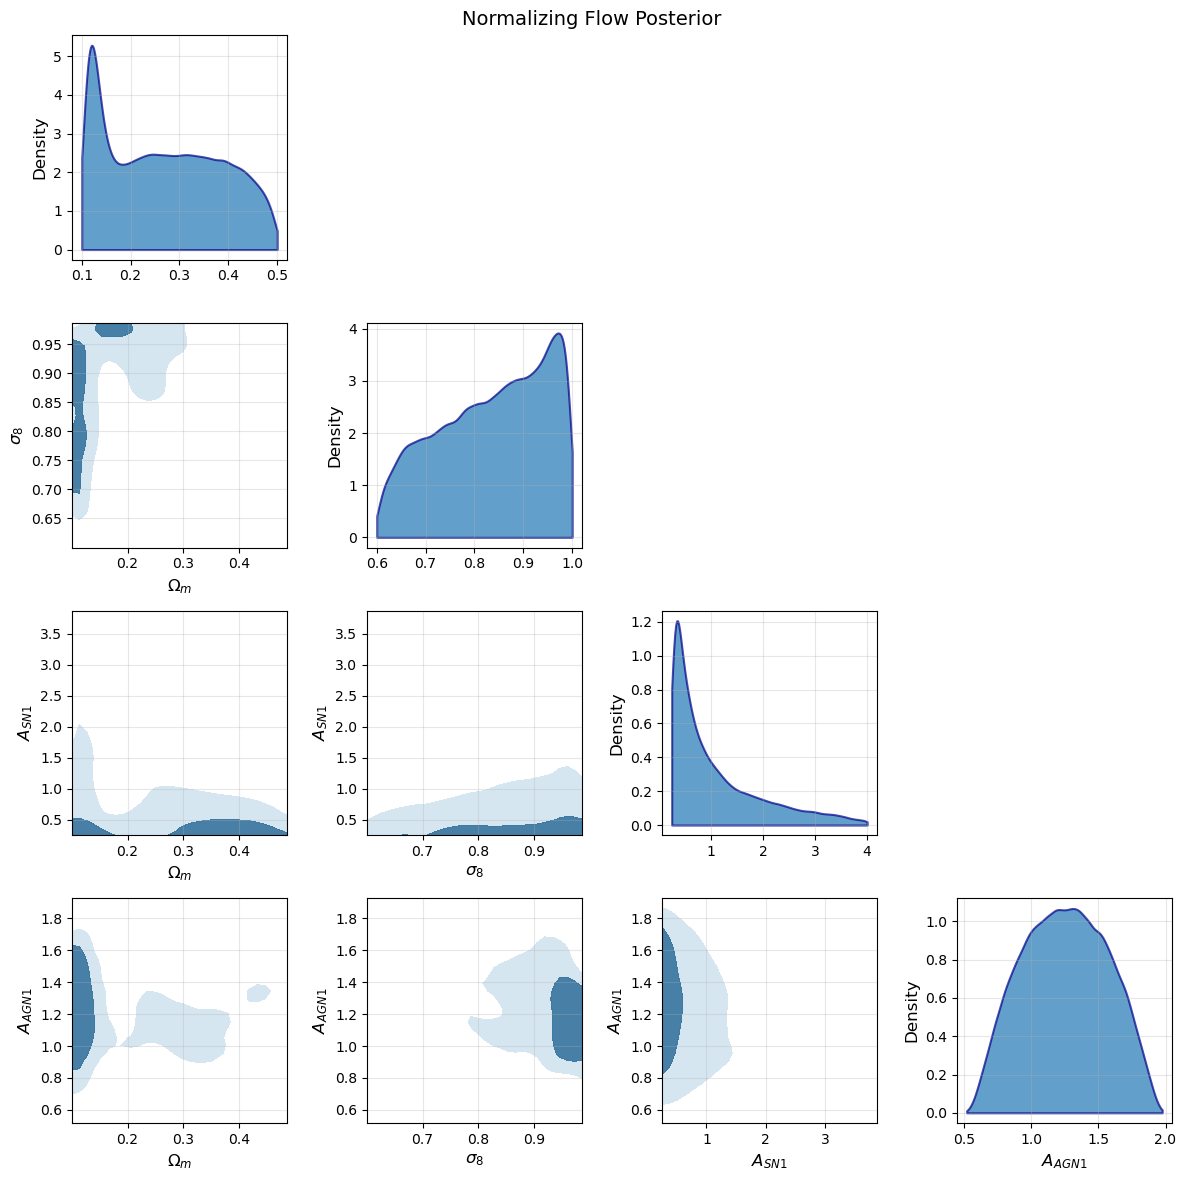

In [50]:
# Check your data structure first
n_unique, n_total, counts = check_many_to_one_mapping(
    np.asarray(TNG_features).squeeze(), 
    np.concatenate((TNG_cosmo_params, np.asarray(TNG_astro_params)[:,:,[0,2]]), axis=2).squeeze()
)


# Then run the flow analysis
model, scaler, samples, means, stds = run_flow_posterior_analysis(
    features_reduced, TNG_cosmo_params, TNG_astro_params
)

In [ ]:
EAGLE_features, EAGLE_labels, EAGLE_astro_params, EAGLE_cosmo_params = feature_extraction(simulation_models=['EAGLE'],
                                                                                  n_samples_per_model=15000)
Astrid_features, Astrid_labels, Astrid_astro_params, Astrid_cosmo_params = feature_extraction(simulation_models=['Astrid'],
                                                                                  n_samples_per_model=15000)
SIMBA_features, SIMBA_labels, SIMBA_astro_params, SIMBA_cosmo_params = feature_extraction(simulation_models=['SIMBA'],
                                                                                  n_samples_per_model=15000)

In [ ]:
def create_multi_simulation_corner_plot(models_data, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'], 
                                       figsize=(15, 15), n_samples_per_model=3000, n_points_per_model=10):
    """
    Create a combined corner plot from multiple simulation models
    """
    
    print(f"Creating combined corner plot for {len(models_data)} simulation models...")
    
    # Colors for different simulations (fallback if not provided)
    default_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
    
    # Sample posteriors from each model
    all_samples = {}
    
    for i, model_data in enumerate(models_data):
        model = model_data['model']
        # FIXED: Use correct scaler names
        input_scaler = model_data['input_scaler'] 
        output_scaler = model_data['output_scaler']
        X_test = model_data['X_test']
        y_test = model_data['y_test']
        device = model_data['device']
        sim_name = model_data.get('name', f'Simulation_{i+1}')
        
        print(f"Sampling from {sim_name}...")
        
        # Select random test points for this model
        n_available = len(X_test)
        n_to_use = min(n_points_per_model, n_available)
        indices = np.random.choice(n_available, n_to_use, replace=False)
        X_demo = X_test[indices]
        
        # FIXED: Pass both scalers correctly
        posterior_samples = sample_posterior_mdn(model, X_demo, input_scaler, output_scaler, device, n_samples=n_samples_per_model)
        
        # Flatten samples from all test points for this simulation
        samples_flat = posterior_samples.reshape(-1, posterior_samples.shape[-1])
        
        all_samples[sim_name] = {
            'samples': samples_flat,
            'color': model_data.get('color', default_colors[i % len(default_colors)]),
            'n_points': n_to_use,
            'n_samples': len(samples_flat)
        }
    
    # Create corner plot
    n_params = len(param_names)
    fig, axes = plt.subplots(n_params, n_params, figsize=figsize)
    
    if n_params == 1:
        axes = np.array([[axes]])
    
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            
            if i < j:
                # Upper triangle: hide
                ax.set_visible(False)
                continue
            elif i == j:
                # Diagonal: marginal distributions for each simulation
                for sim_name, sim_data in all_samples.items():
                    samples = sim_data['samples']
                    color = sim_data['color']
                    data = samples[:, i]
                    
                    if len(data) > 10:  # Only plot if we have enough data
                        try:
                            kde = gaussian_kde(data)
                            x_range = np.linspace(data.min(), data.max(), 200)
                            density = kde(x_range)
                            ax.plot(x_range, density, color=color, linewidth=2, 
                                   alpha=0.8, label=sim_name)
                            ax.fill_between(x_range, density, alpha=0.3, color=color)
                        except:
                            # Fallback to histogram
                            ax.hist(data, bins=30, density=True, alpha=0.5, 
                                   color=color, label=sim_name, histtype='step', linewidth=2)
                
                ax.set_ylabel('Density', fontsize=12)
                if i == n_params - 1:
                    ax.set_xlabel(param_names[i], fontsize=12)
                
                # Add legend to first diagonal plot
                if i == 0:
                    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
                
            else:
                # Lower triangle: joint distributions with sunny egg style
                for sim_name, sim_data in all_samples.items():
                    samples = sim_data['samples']
                    color = sim_data['color']
                    x_data = samples[:, j]  # x-axis dimension
                    y_data = samples[:, i]  # y-axis dimension
                    
                    if len(x_data) > 50:  # Only plot if we have enough data
                        try:
                            # Estimate 2D density using histogram + smoothing
                            H, xedges, yedges = np.histogram2d(x_data, y_data, bins=25, density=True)
                            from scipy.ndimage import gaussian_filter
                            H = gaussian_filter(H, sigma=1.0)
                            X_grid, Y_grid = np.meshgrid(xedges[:-1], yedges[:-1])
                            density = H.T
                            
                            # Sunny egg color scheme
                            from matplotlib.colors import to_rgba
                            base_rgba = to_rgba(color)
                            
                            # Outer: lighter (mix with white)
                            mix_factor = 0.7
                            outer_color = tuple(base_rgba[k] * (1-mix_factor) + mix_factor for k in range(3)) + (0.6,)
                            
                            # Inner: darker (multiply RGB values)  
                            darken_factor = 0.8
                            inner_color = tuple(base_rgba[k] * darken_factor for k in range(3)) + (0.8,)
                            
                            # Create two levels for sunny egg effect
                            max_density = density.max()
                            min_density = density.min()
                            
                            # Use percentiles of the actual density values
                            low_level = np.percentile(density, 80)   # 80th percentile
                            high_level = np.percentile(density, 95)  # 95th percentile
                            
                            # Ensure we have meaningful levels
                            if low_level >= high_level:
                                low_level = min_density + (max_density - min_density) * 0.4
                                high_level = min_density + (max_density - min_density) * 0.8
                            
                            # Fill outer ring (lighter)
                            ax.contourf(X_grid, Y_grid, density, 
                                       levels=[low_level, high_level], 
                                       colors=[outer_color], alpha=0.6)
                            
                            # Fill inner core (darker)
                            ax.contourf(X_grid, Y_grid, density, 
                                       levels=[high_level, max_density], 
                                       colors=[inner_color], alpha=0.8)
                            
                        except Exception as e:
                            print(f"Could not create density plot for {sim_name}: {e}")
                            # Fallback: scatter plot with subsampling
                            sample_idx = np.random.choice(len(x_data), min(500, len(x_data)), replace=False)
                            ax.scatter(x_data[sample_idx], y_data[sample_idx], 
                                     color=color, alpha=0.4, s=5, label=sim_name)
                
                ax.set_xlabel(param_names[j], fontsize=12)
                ax.set_ylabel(param_names[i], fontsize=12)
            
            # Styling
            ax.grid(True, alpha=0.3)
    
    # Create title with simulation info
    sim_names = list(all_samples.keys())
    title = f"Combined Posterior: {', '.join(sim_names)}"
    plt.suptitle(title, fontsize=16, y=0.98)
    
    plt.tight_layout()
    plt.savefig('combined_posterior_corner_plot.png', dpi=300, bbox_inches='tight')
    
    # Print summary statistics
    print("\nSummary:")
    for sim_name, sim_data in all_samples.items():
        print(f"{sim_name}: {sim_data['n_samples']} samples from {sim_data['n_points']} test points")
    
    return fig, axes, all_samples

def run_multi_simulation_analysis(simulation_datasets, param_names=None):
    """
    Train MDNs on multiple simulations and create combined corner plot
    """
    
    if param_names is None:
        param_names = ['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$']
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    models_data = []
    
    # Train MDN for each simulation
    for i, sim_data in enumerate(simulation_datasets):
        sim_name = sim_data.get('name', f'Simulation_{i+1}')
        print(f"\n{'='*50}")
        print(f"Training MDN for {sim_name}")
        print(f"{'='*50}")
        
        # Extract and prepare data
        features = np.asarray(sim_data['features']).squeeze()
        cosmo_params = sim_data['cosmo_params']
        astro_params = sim_data['astro_params']
        
        # Combine parameters
        parameters = np.concatenate((cosmo_params, np.asarray(astro_params)[:,:,[0,2]]), axis=2).squeeze()
        
        # Train MDN - FIXED: capture both scalers
        model, input_scaler, output_scaler, train_losses, test_losses, X_test, y_test = train_mdn(
            features, parameters, n_components=2, epochs=150
        )
        
        # FIXED: Store both scalers with correct names
        models_data.append({
            'model': model,
            'input_scaler': input_scaler,
            'output_scaler': output_scaler,
            'X_test': X_test,
            'y_test': y_test,
            'device': device,
            'name': sim_name,
            'color': sim_data.get('color', None),
            'train_losses': train_losses,
            'test_losses': test_losses
        })
    
    # Create combined corner plot
    print(f"\n{'='*50}")
    print("Creating Combined Corner Plot")
    print(f"{'='*50}")
    
    fig, axes, all_samples = create_multi_simulation_corner_plot(
        models_data, param_names=param_names, n_points_per_model=15
    )
    
    plt.show()
    
    return models_data, fig, all_samples


In [ ]:
simulation_datasets = [
    {
        'features': TNG_features,
        'cosmo_params': TNG_cosmo_params, 
        'astro_params': TNG_astro_params,
        'name': 'IllustrisTNG',
        'color': '#1f77b4'
    },
    {
        'features': EAGLE_features,
        'cosmo_params': EAGLE_cosmo_params,
        'astro_params': EAGLE_astro_params, 
        'name': 'EAGLE',
        'color': '#ff7f0e'
    },
    {
        'features': Astrid_features,
        'cosmo_params': Astrid_cosmo_params,
        'astro_params': Astrid_astro_params,
        'name': 'Astrid', 
        'color': '#2ca02c'
    },
    {
        'features': SIMBA_features,
        'cosmo_params': SIMBA_cosmo_params,
        'astro_params': SIMBA_astro_params,
        'name': 'SIMBA',
        'color': '#d62728'
    }
]

# Run the analysis
models_data, fig, all_samples = run_multi_simulation_analysis(
    simulation_datasets, 
    param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$']
)
